# Neural Network from Scratch

            ## 1. Learning objectives

            - Implement forward propagation
- Derive and code two-layer backpropagation
- Compare NumPy and PyTorch on XOR

            ## 2. Prerequisites

            NumPy arrays, matrix multiplication, basic derivatives, and the supervised-learning workflow.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")


import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_num_threads(1)
device = torch.device("cpu")
print("PyTorch:", torch.__version__, "| device:", device)

Python lesson ready; reproducible seed = 42
PyTorch: 2.14.0+cpu | device: cpu


## 3. Problem definition

            Learn a nonlinear decision function that a single perceptron cannot represent.

            ## 4. Real-world use cases

            - Image recognition
- Sequence modeling
- Learned feature representations

            ## 5. Core intuition in simple language

            Hidden neurons create several intermediate boundaries; the output combines them into a nonlinear pattern.

## 6. Mathematical foundation

            $$\frac{\partial L}{\partial W_1}=\mathbf{X}^{T}\left[\left(\frac{\partial L}{\partial z_2}W_2^T\right)\odot(1-\mathbf{h}^2)\right].$$

            **Every symbol:**

            - $L$ is binary cross-entropy loss.
- $W_1,W_2$ are layer weights.
- $z_2$ is output pre-activation.
- $\mathbf{h}$ is tanh hidden activation.
- $\odot$ is elementwise multiplication.

            **Why the equation is needed:** The chain rule carries output error backward through the second layer and tanh derivative.

            **Small numerical example:** If an upstream gradient is .4 and a tanh activation is .5, the local gradient multiplier is .4(1-.5^2)=.3.

            **Connection to Python:** hidden_gradient = (output_gradient @ W2.T) * (1 - hidden**2).

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Create tensors with explicit batch and feature dimensions
2. Run a forward pass
3. Compute a loss against targets
4. Backpropagate gradients
5. Update parameters with an optimizer
6. Evaluate on untouched validation data

## 9. Implementation from scratch

NumPy exposes the forward calculation and, where appropriate, the gradients.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def sigmoid(values):
    return 1 / (1 + np.exp(-np.clip(values, -30, 30)))

X = np.array([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y = np.array([[0.],[1.],[1.],[0.]])
W1 = rng.normal(0, .8, size=(2, 4)); b1 = np.zeros((1, 4))
W2 = rng.normal(0, .8, size=(4, 1)); b2 = np.zeros((1, 1))
learning_rate = .8
losses = []
for epoch in range(4000):
    hidden = np.tanh(X @ W1 + b1)
    prediction = sigmoid(hidden @ W2 + b2)
    loss = -np.mean(y*np.log(prediction+1e-9)+(1-y)*np.log(1-prediction+1e-9))
    losses.append(loss)
    output_gradient = (prediction - y) / len(X)
    dW2 = hidden.T @ output_gradient; db2 = output_gradient.sum(axis=0, keepdims=True)
    hidden_gradient = (output_gradient @ W2.T) * (1 - hidden**2)
    dW1 = X.T @ hidden_gradient; db1 = hidden_gradient.sum(axis=0, keepdims=True)
    W2 -= learning_rate*dW2; b2 -= learning_rate*db2
    W1 -= learning_rate*dW1; b1 -= learning_rate*db1
print("Shapes:", X.shape, hidden.shape, prediction.shape)
print("Final XOR predictions:", (prediction.ravel() >= .5).astype(int), "loss:", round(losses[-1], 4))

Shapes: (4, 2) (4, 4) (4, 1)
Final XOR predictions: [0 1 1 0] loss: 0.0007


## 10. Implementation using a standard library

PyTorch tensors, modules, autograd, losses, and optimizers provide the standard implementation.

## 11. Dataset loading and exploration

Every lesson uses a generated sequence or a small dataset bundled with scikit-learn; no download is required.

## 12. Data preprocessing

Splits occur before fitted transformations. Inputs are converted to float32 tensors and class labels to int64.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Model diagnostics: {'input_shape': (256, 2), 'intermediate_shape': (256, 4), 'output_shape': (256, 1), 'trainable_parameters': 17, 'final_training_loss': 0.0006, 'final_validation_loss': 0.0006, 'truth_table_accuracy': 1.0}
Truth-table predictions: [0 1 1 0]


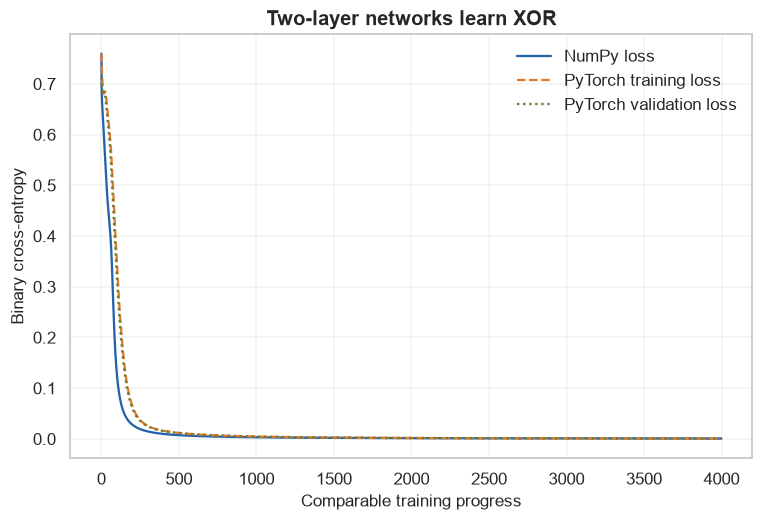

In [3]:
torch_model = nn.Sequential(nn.Linear(2, 4), nn.Tanh(), nn.Linear(4, 1))
optimizer = torch.optim.Adam(torch_model.parameters(), lr=.08)
loss_fn = nn.BCEWithLogitsLoss()
training_features = np.repeat(X, 64, axis=0) + rng.normal(0, .04, size=(256, 2))
training_targets = np.repeat(y, 64, axis=0)
validation_features = np.repeat(X, 24, axis=0) + rng.normal(0, .04, size=(96, 2))
validation_targets = np.repeat(y, 24, axis=0)
Xt = torch.tensor(training_features, dtype=torch.float32)
yt = torch.tensor(training_targets, dtype=torch.float32)
Xv = torch.tensor(validation_features, dtype=torch.float32)
yv = torch.tensor(validation_targets, dtype=torch.float32)
torch_losses = []; torch_validation_losses = []
for epoch in range(800):
    torch_model.train()
    optimizer.zero_grad()
    logits = torch_model(Xt)
    loss = loss_fn(logits, yt)
    loss.backward()
    optimizer.step()
    torch_model.eval()
    with torch.no_grad():
        validation_logits = torch_model(Xv)
        validation_loss = loss_fn(validation_logits, yv)
    torch_losses.append(loss.item())
    torch_validation_losses.append(validation_loss.item())
with torch.no_grad():
    truth_table_logits = torch_model(torch.tensor(X, dtype=torch.float32))
    torch_prediction = (torch.sigmoid(truth_table_logits).ravel() >= .5).int().numpy()
    hidden_activations = torch_model[1](torch_model[0](Xt))
truth_table_accuracy = float(np.mean(torch_prediction == y.ravel()))
print("Model diagnostics:", {
    "input_shape": tuple(Xt.shape),
    "intermediate_shape": tuple(hidden_activations.shape),
    "output_shape": tuple(logits.shape),
    "trainable_parameters": sum(p.numel() for p in torch_model.parameters()),
    "final_training_loss": round(torch_losses[-1], 4),
    "final_validation_loss": round(torch_validation_losses[-1], 4),
    "truth_table_accuracy": round(truth_table_accuracy, 3),
})
print("Truth-table predictions:", torch_prediction)

figure, axis = plt.subplots()
axis.plot(losses, label="NumPy loss", color=COURSE_COLORS["blue"])
progress = np.linspace(0, len(losses)-1, len(torch_losses))
axis.plot(progress, torch_losses, label="PyTorch training loss", color=COURSE_COLORS["orange"], linestyle="--")
axis.plot(progress, torch_validation_losses, label="PyTorch validation loss", color=COURSE_COLORS["olive"], linestyle=":")
axis.set(title="Two-layer networks learn XOR", xlabel="Comparable training progress", ylabel="Binary cross-entropy")
axis.legend()
plt.show()

**How to interpret the result:** Both implementations drive loss down and reproduce all four XOR labels, validating the manual gradients against autograd.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

A width of one cannot reliably form XOR's two disjoint positive regions; extra units add capacity and parameters.

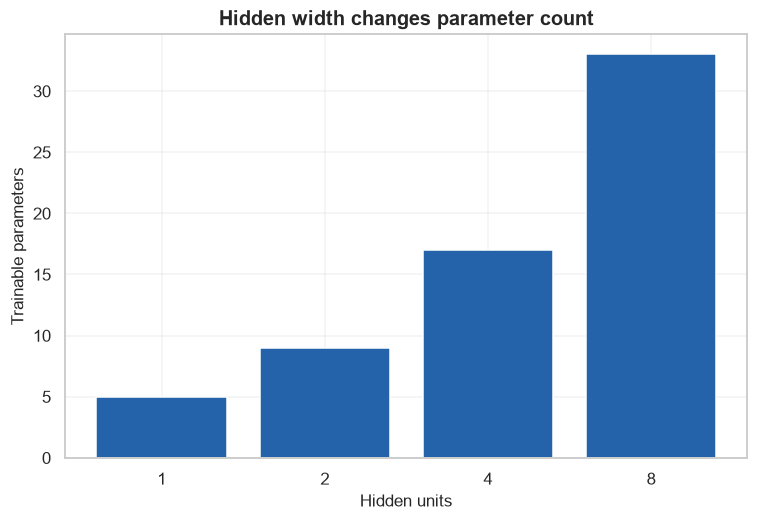

In [4]:
widths = [1, 2, 4, 8]
parameter_counts = [2*w + w + w + 1 for w in widths]
figure, axis = plt.subplots()
axis.bar([str(w) for w in widths], parameter_counts, color=COURSE_COLORS["blue"])
axis.set(title="Hidden width changes parameter count", xlabel="Hidden units", ylabel="Trainable parameters")
plt.show()

## 18. Common mistakes

            - Forgetting batch and feature dimensions
- Applying softmax before CrossEntropyLoss
- Evaluating on the training set
- Leaving gradients accumulated between optimizer steps

            ## 19. Advantages and disadvantages

            **Advantages**

            - Learns features jointly with predictions
- Flexible building blocks for structured data

            **Disadvantages**

            - Needs careful optimization and validation
- Can be computationally expensive and difficult to interpret

            ## 20. When to use and when not to use the algorithm

            **Use it when:** the data and task benefit from learned nonlinear representations and validation supports the added complexity.

            **Do not use it when:** a small tabular dataset is handled well by a simpler, easier-to-audit model.

## 21. Exercises

1. **Conceptual:** Why do hidden layers need nonlinear activations?
2. **Mathematical/hand calculation:** Calculate ReLU([−2, 0, 3]).
3. **Coding/experimentation:** Double hidden width and compare parameter count and validation behavior.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Without nonlinearities, multiple affine layers equal one affine layer.
2. The result is [0, 0, 3].
3. Change the layer width, count parameters, retrain with the same split, and compare training-versus-validation loss rather than training loss alone.

</details>

## 23. Summary and key takeaways

            - Tensor shapes are part of the model specification
- Forward propagation produces predictions and backpropagation produces gradients
- Training and validation curves reveal optimization and generalization

            ## 24. Further reading

            - [PyTorch tutorials](https://pytorch.org/tutorials/)
- [PyTorch neural-network modules](https://pytorch.org/docs/stable/nn.html)